# Task 1 EDA: news acquisition, filtering, and alignment

Evidence behind the design choices in the README. Runs only on files committed to the repo
(`data/processed/` and `data/raw_sample/`), so it can be re-run straight after cloning.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
SAMPLE = ROOT / "data" / "raw_sample"

dataset = pd.read_csv(PROCESSED / "final_dataset.csv", parse_dates=["date"])
articles = pd.read_parquet(PROCESSED / "articles_aligned")
print(f"{len(dataset)} trading days, {len(articles)} aligned articles")

1202 trading days, 243844 aligned articles


## 1. What the raw data looks like
A few raw GDELT GKG rows (the discovery index) and one scraped article.

In [2]:
raw = pd.read_csv(SAMPLE / "gdelt_id_sample.csv")
raw[["gdelt_timestamp", "SourceCommonName", "title", "url"]].head()

,gdelt_timestamp,SourceCommonName,title,url
0,20211005091500,bisnis.com,Bulan Inklusi Keuangan Dorong Kebangkitan Sekt...,https://sulawesi.bisnis.com/read/20211005/539/...
1,20211005091500,bisnis.com,"HUT TNI, Setara Institute Soroti Maraknya Keke...",https://kabar24.bisnis.com/read/20211005/16/14...
2,20211005091500,bisnis.com,"Lowongan Kerja di BUMN Jasa Tirta I, Ini Syara...",https://kabar24.bisnis.com/read/20211005/243/1...
3,20211005091500,bisnis.com,"Said Iqbal Pimpin Partai Buruh, Berikut Organi...",https://kabar24.bisnis.com/read/20211005/15/14...
4,20211005091500,bisnis.com,Pidato Lengkap Jokowi di Upacara Peringatan HU...,https://kabar24.bisnis.com/read/20211005/15/14...


In [3]:
with open(SAMPLE / "articles_bisnis_sample.jsonl", encoding="utf-8") as f:
    first = json.loads(f.readline())
print(first["title"]); print(first["body"][:600], "...")

Proyeksi Saham Bank Jumbo BBCA, BBRI, BMRI, BBNI pada 2024
Bisnis.com , JAKARTA — Emiten bank jumbo seperti PT Bank Central Asia Tbk. ( BBCA ) hingga PT Bank Mandiri (Persero) Tbk. (BMRI) mencatatkan kinerja harga saham yang moncer sepanjang 2023. Bagaimana proyeksi reli saham bank-bank big caps ini pada 2024?
Berdasarkan data RTI Business, harga saham BBCA naik 9,94% sepanjang tahun berjalan ( year to date /ytd) dan ditutup pada level Rp9.400 pada perdagangan bursa akhir 2023, Jumat (29/12/2023). Harga saham BMRI pun naik 21,91% ytd dan terparkir di level Rp6.050 pada akhir 2023.
Kemudian, harga saham PT Bank Rakyat Indonesia (Persero) Tbk. ( BBRI )  ...


## 2. Filter funnel
How many rows each filtering stage keeps (from `filter_report.json`).

,stage,count
0,raw_pulled,492777
1,after_url_dedupe,492750
2,after_section_filter,252302
3,after_theme_filter,245162
4,scrape_queue_after_daily_cap,39837
5,id_headlines_raw,245162
6,id_headlines_after_empty_title_drop,245162
7,id_headlines_after_cross_site_title_dedupe,244823
8,global_headlines_raw,0
9,bodies_scraped,10594


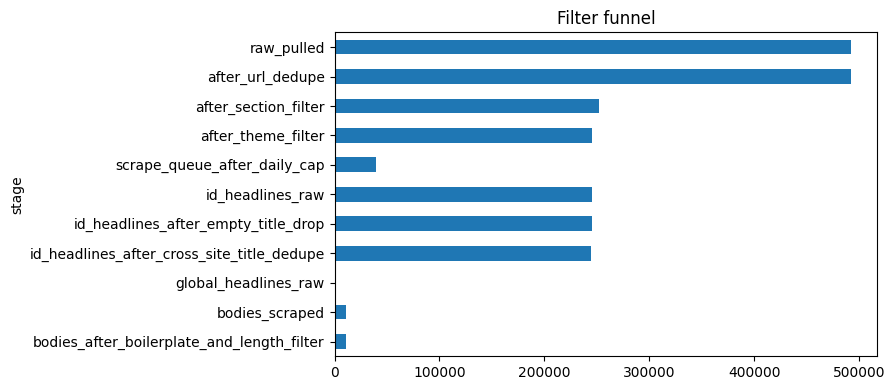

In [4]:
with open(PROCESSED / "filter_report.json") as f:
    funnel = pd.DataFrame(json.load(f)["stages"])[["stage", "count"]]
display(funnel)
ax = funnel.plot.barh(x="stage", y="count", legend=False, figsize=(9, 4), title="Filter funnel")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 3. News coverage over time
Articles per month per source. Kontan only appears from 2023-03 (GDELT coverage gap), and
GDELT's own Indonesian coverage collapses from Aug 2022 to Jan 2023 (~500 raw rows/month
instead of ~7,000), which is why those months have many zero-news trading days.

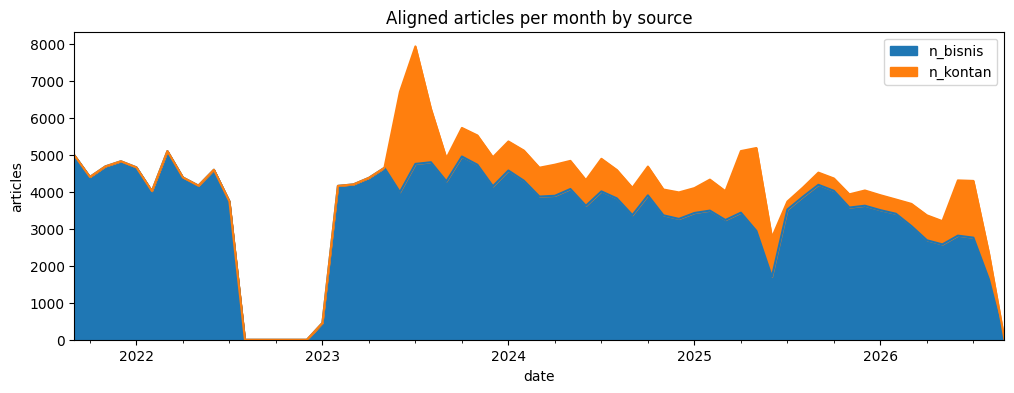

trading days with zero news: 144
date
2022-07     5
2022-08    22
2022-09    22
2022-10    21
2022-11    22
2022-12    22
2023-01    19
2025-06     9
2025-07     2
Freq: M, Name: count, dtype: int64


In [5]:
monthly = dataset.set_index("date")[["n_bisnis", "n_kontan"]].resample("MS").sum()
monthly.plot.area(figsize=(12, 4), title="Aligned articles per month by source")
plt.ylabel("articles"); plt.show()
zero = dataset[dataset["n_articles"] == 0]
print(f"trading days with zero news: {len(zero)}")
print(zero["date"].dt.to_period("M").value_counts().sort_index())

## 4. Alignment rule in practice
Each article goes to the first JISDOR fixing (10:00 WIB) at or after its timestamp.
Most articles are published after 10:00, so they count toward the *next* trading day.

{'articles_loaded': 244823,
 'articles_on_or_after_start': 244823,
 'articles_after_last_fixing_dropped': 979,
 'articles_aligned': 243844,
 'alignment_cases': {'after_cutoff': 155438,
  'non_trading_day': 46685,
  'same_day': 41721},
 'cutoff_time_wib': '10:00'}

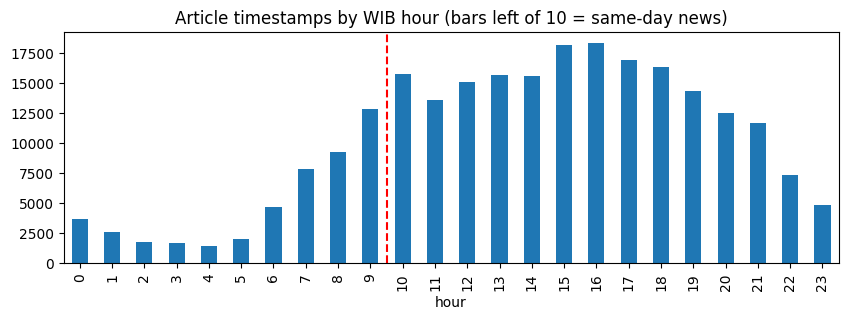

In [6]:
with open(PROCESSED / "alignment_report.json") as f:
    display(json.load(f))
articles["hour"] = articles["timestamp_wib"].dt.hour
ax = articles["hour"].value_counts().sort_index().plot.bar(figsize=(10, 3),
    title="Article timestamps by WIB hour (bars left of 10 = same-day news)")
ax.axvline(9.5, color="red", ls="--"); plt.show()

In [7]:
# Worked examples of each case
cols = ["timestamp_wib", "calendar_date_wib", "trading_date", "alignment_case", "title"]
articles.groupby("alignment_case").sample(2, random_state=0)[cols]

,timestamp_wib,calendar_date_wib,trading_date,alignment_case,title
110847,2024-01-08 12:45:00+07:00,2024-01-08,2024-01-09,after_cutoff,"Cadangan Devisa Indonesia Melonjak ke US$146,4..."
2825,2021-09-16 19:00:00+07:00,2021-09-16,2021-09-17,after_cutoff,Pemerintah Dorong Pemanfaatan BBM yang Lebih B...
28308,2022-03-03 11:30:00+07:00,2022-03-03,2022-03-04,non_trading_day,Manajemen BCA: M-Banking BCA Sudah Normal Lagi...
123758,2024-03-23 13:45:00+07:00,2024-03-23,2024-03-25,non_trading_day,"IHSG Pekan Ini Naik, Cek 10 Saham Paling Laris..."
29297,2022-03-10 06:45:00+07:00,2022-03-10,2022-03-10,same_day,"Nanotech (NANO) Siap Melantai di Bursa, Raup D..."
143975,2024-08-05 10:00:00+07:00,2024-08-05,2024-08-05,same_day,Medco Energy (MEDC) Serap Capex US$188 Juta Se...


## 5. USD/IDR (Bank Indonesia JISDOR)

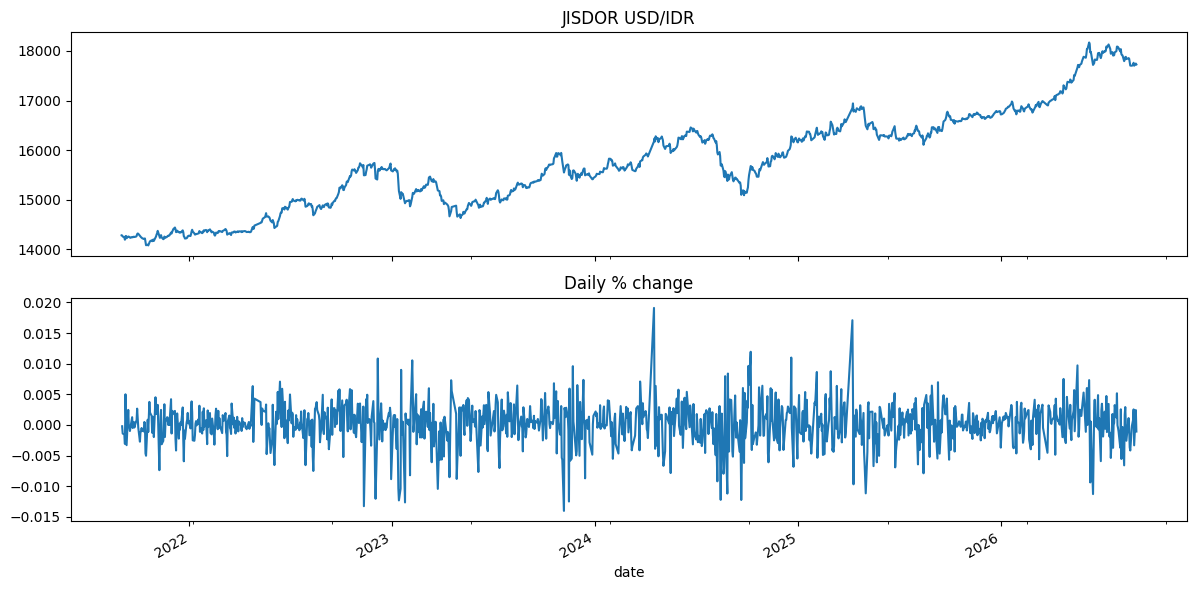

direction
up (IDR weaker)        665
down (IDR stronger)    523
flat                    13
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
dataset.plot(x="date", y="jisdor_rate", ax=axes[0], legend=False, title="JISDOR USD/IDR")
dataset.plot(x="date", y="pct_change", ax=axes[1], legend=False, title="Daily % change")
plt.tight_layout(); plt.show()
print(dataset["direction"].value_counts().rename({1: "up (IDR weaker)", -1: "down (IDR stronger)", 0: "flat"}))

## 6. News volume vs. size of the move
A first look (no modelling yet): are big JISDOR moves accompanied by more news?

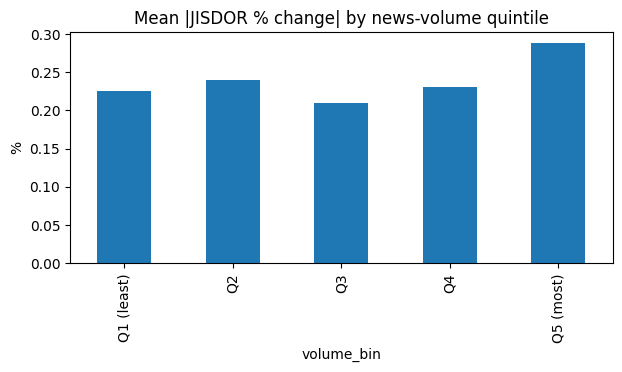

In [9]:
d = dataset[dataset["n_articles"] > 0].copy()
d["abs_move_pct"] = d["pct_change"].abs() * 100
d["volume_bin"] = pd.qcut(d["n_articles"], 5, labels=["Q1 (least)", "Q2", "Q3", "Q4", "Q5 (most)"])
d.groupby("volume_bin", observed=True)["abs_move_pct"].mean().plot.bar(
    figsize=(7, 3), title="Mean |JISDOR % change| by news-volume quintile")
plt.ylabel("%"); plt.show()